# Mnist example

## Libs and data

In [1]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist

# Split the dataset into training and test sets with features and labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display the shapes of the datasets
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

# The x data is a 3-d array (images, width, height) of grayscale values.
# The y data is an integer vector with values ranging from 0 to 9.

11490434/11490434 [==============================] - 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Visualize the 9 first digits from training set

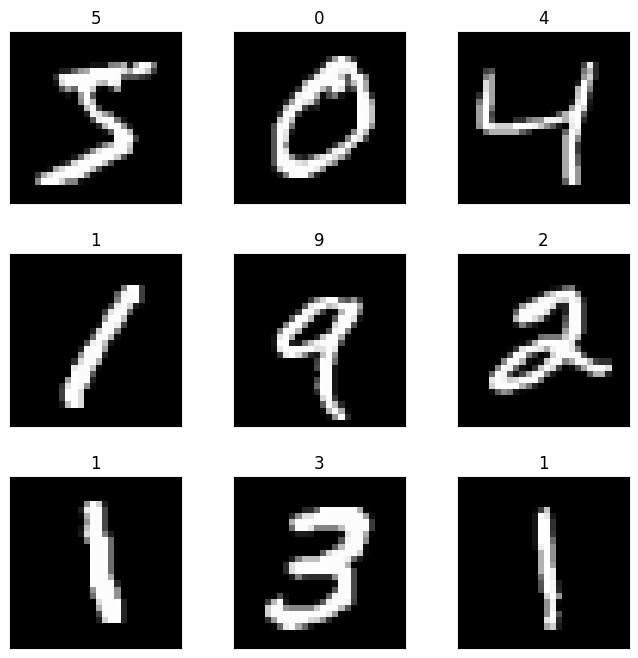

In [2]:
# Create a 3x3 subplot
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

for i, ax in enumerate(axes.flat):
    im = x_train[i]
    ax.imshow(im, cmap='gray')
    ax.set_title(f'{y_train[i]}')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## Data prepare
To prepare the data for training we convert the 3-d arrays into matrices by reshaping width and height into a single dimension (28x28 images are flattened into length 784 vectors). Then, we convert the grayscale values from integers ranging between 0 to 255 into floating point values ranging between 0 and 1

In [3]:
# Reshape
x_train = x_train.reshape(x_train.shape[0], 28 * 28)
x_test = x_test.reshape(x_test.shape[0], 28 * 28)

# Rescale
x_train = x_train / 255.0
x_test = x_test / 255.0

To prepare this data for training we one-hot encode the vectors into binary class matrices using the Keras `to_categorical()` function. One hot encoding is a vector representation where all elements of the vector are 0 except one, which has 1 as its value (assigning 1 to working feature and 0’s to other idle features).

In [4]:
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

## Defining the model
The core data structure of Keras is a model, a way to organize layers. The simplest type of model is the Sequential model, a linear stack of layers.

In [5]:
# Create the model
model = Sequential()
model.add(Dense(256, activation='relu', input_shape = (28 * 28,))) # 784 * 256 + 256 = 200 960
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu')) # 256 * 128 + 128 = 32 896
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax')) # 128 * 10 + 10 = 1290

The input_shape argument to the first layer specifies the shape of the input data (a length 784 numeric vector representing a grayscale image). The final layer outputs a length 10 numeric vector (probabilities for each digit) using a softmax activation function. Softmax activation function takes as input a vector of $K$ real numbers, and normalizes it into a probability distribution consisting of K probabilities proportional to the exponentials of the input numbers $$f_i(\pmb z) = \frac{e^{z_{i}}}{\sum_{j=1}^Ke^{z_{j}}}.$$

In [6]:
# Display the model's architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 235146 (918.54 KB)
Trainable params: 235146 (918.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Compile the model
* Loss function -- This measures how accurate the model is during training. We want to minimize this function to 'steer' the model in the right direction.
* Optimizer -- This is how the model is updated based on the data it sees and its loss function.
* Metrics -- Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the digits that are correctly classified.

In [7]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

In [8]:
x_train.shape

(60000, 784)

## Training the model

Epoch 1/50
375/375 [==============================] - 6s 5ms/step - loss: 0.4560 - accuracy: 0.8624 - val_loss: 0.1660 - val_accuracy: 0.9502
Epoch 2/50
375/375 [==============================] - 1s 4ms/step - loss: 0.1995 - accuracy: 0.9399 - val_loss: 0.1154 - val_accuracy: 0.9658
Epoch 3/50
375/375 [==============================] - 1s 4ms/step - loss: 0.1547 - accuracy: 0.9530 - val_loss: 0.1030 - val_accuracy: 0.9689
Epoch 4/50
375/375 [==============================] - 1s 4ms/step - loss: 0.1266 - accuracy: 0.9615 - val_loss: 0.0952 - val_accuracy: 0.9722
Epoch 5/50
375/375 [==============================] - 1s 4ms/step - loss: 0.1121 - accuracy: 0.9660 - val_loss: 0.0925 - val_accuracy: 0.9726
Epoch 6/50
375/375 [==============================] - 2s 5ms/step - loss: 0.0975 - accuracy: 0.9698 - val_loss: 0.0858 - val_accuracy: 0.9741
Epoch 7/50
375/375 [==============================] - 2s 5ms/step - loss: 0.0884 - accuracy: 0.9720 - val_loss: 0.0823 - val_accuracy: 0.9751
Epoch 

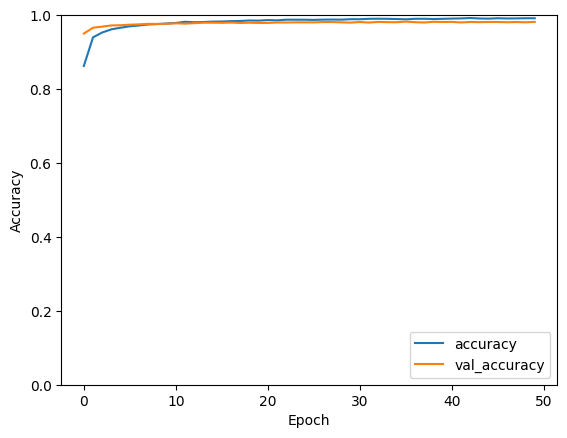

In [9]:
# Fit the model
history = model.fit(
    x_train,
    y_train,
    epochs = 50, # Number of epochs
    batch_size = 128, # Size of batch in single step; 48 000 / 128 = 375 batches
    validation_split = 0.2 # Percent of data in validation sets
)

# Plot the training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

## Evaluate the model

In [10]:
# Evaluate the model's performance on the train data
train_loss, train_accuracy = model.evaluate(x_train, y_train)
print(f'Train accuracy: {train_accuracy:.4f}')

# Evaluate the model's performance on the test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

1875/1875 [==============================] - 5s 3ms/step - loss: 0.0186 - accuracy: 0.9960
Train accuracy: 0.9960
313/313 [==============================] - 1s 2ms/step - loss: 0.0815 - accuracy: 0.9825
Test accuracy: 0.9825


It turns out, the accuracy on the test dataset is a little less than the accuracy on the training dataset. This gap between training accuracy and test accuracy is an example of overfitting. Overfitting is when a machine learning model performs worse on new data than on their training data

## Predictions

In [12]:
# Predicted probabilities on test data
predictions = model.predict(x_test)
print(predictions)

# Predicted digits on test data
predicted_digits = np.argmax(predictions, axis=1)

print(predicted_digits)

313/313 [==============================] - 1s 4ms/step
[[2.9139109e-15 1.3281293e-15 3.3620285e-13 ... 1.0000000e+00
  5.7709277e-18 5.7117981e-09]
 [5.0386550e-20 2.3897491e-09 1.0000000e+00 ... 2.5721733e-16
  6.6907931e-18 1.9031700e-29]
 [2.3528740e-13 1.0000000e+00 2.7040267e-10 ... 4.3794067e-08
  9.8556896e-09 1.3102806e-14]
 ...
 [1.2108979e-19 1.4122724e-14 1.1333548e-17 ... 4.6850229e-11
  2.3761168e-14 2.1923138e-12]
 [2.8763748e-21 4.5818615e-24 1.1891859e-27 ... 7.5079384e-22
  5.8923081e-14 4.3679630e-22]
 [9.6294381e-13 5.5405729e-21 8.3329042e-16 ... 2.3279144e-26
  1.1278294e-18 8.2710599e-22]]
[7 2 1 ... 4 5 6]


A prediction is an array of 10 numbers. These describe the 'confidence' of the model that the image corresponds to each of the 10 different digits. Let's plot several images with their predictions. Correct prediction labels are green and incorrect prediction labels are red.

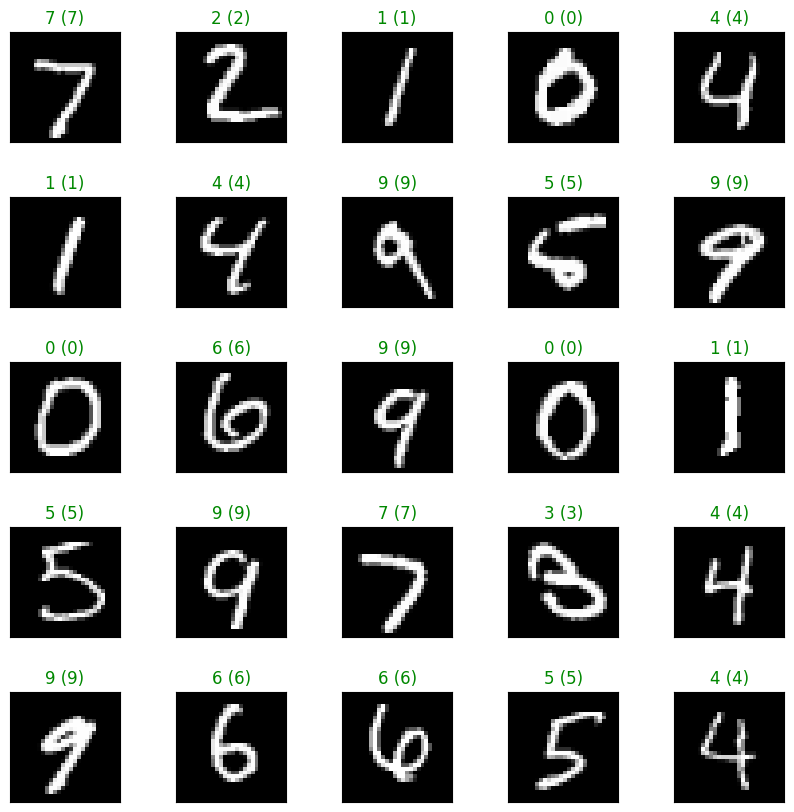

In [13]:
# Create a 5x5 subplot
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

# Plot the first 25 images from the test set with predictions
for i, ax in enumerate(axes.flat):
    img = x_test[i].reshape(28, 28)
    true_label = np.argmax(y_test[i])
    predicted_label = predicted_digits[i]
    if predicted_label == true_label:
        color = '#008800'  # Green for correct predictions
    else:
        color = '#bb0000'  # Red for incorrect predictions

    ax.imshow(img, cmap='gray')
    ax.set_title(f'{predicted_label} ({true_label})', color=color)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## Confusion matrix

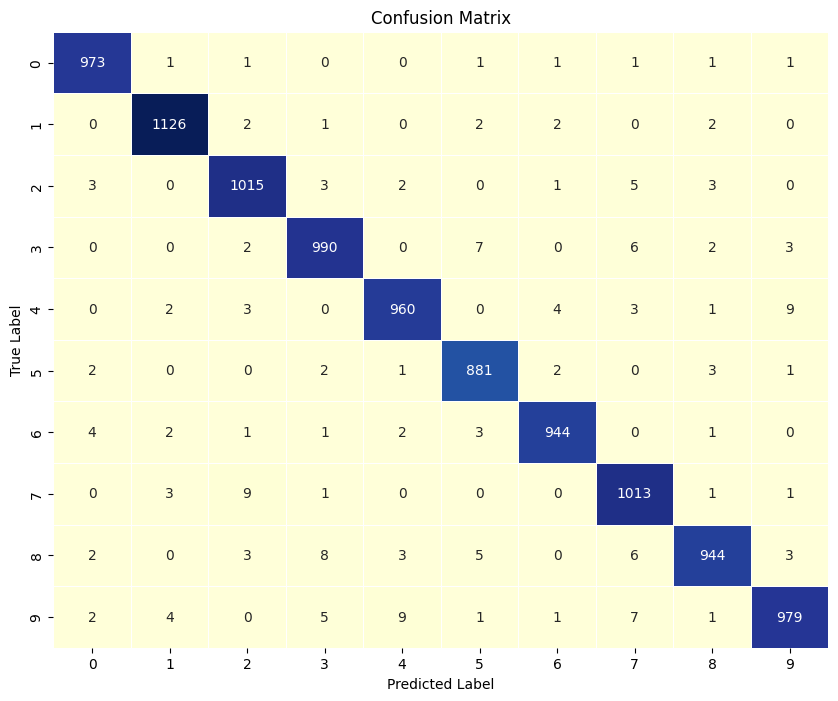

In [14]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(np.argmax(y_test, axis=1), predicted_digits)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False, linewidths=.5)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Boston Housing Prices example
Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. It has 506 total examples that are split between 404 training examples and 102 test examples. The attributes are defined as follows:

1. CRIM: per capita crime rate by town
2. ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3. INDUS: proportion of non-retail business acres per town
4. CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5. NOX: nitric oxides concentration (parts per 10 million)
6. RM: average number of rooms per dwelling
7. AGE: proportion of owner-occupied units built prior to 1940
8. DIS: weighted distances to five Boston employment centers
9. RAD: index of accessibility to radial highways
10. TAX: full-value property-tax rate per \$10,000
11. PTRATIO: pupil-teacher ratio by town 12.
12. B: $1000(B_k - 0.63)^2$ where $B_k$ is the proportion of blacks by town.
13. LSTAT: % lower status of the population
14. MEDV: Median value of owner-occupied homes in \$1000s

Each one of these input data features is stored using a different scale. Some features are represented by a proportion between 0 and 1, other features are ranges between 1 and 12, some are ranges between 0 and 100, and so on.

## Data load

In [15]:
# Load the Boston Housing dataset
boston_housing = tf.keras.datasets.boston_housing

# Split the dataset into training and test sets
(train_data, train_labels), (test_data, test_labels) = boston_housing.load_data()

# Display the shapes of the datasets
print(f'train_data shape: {train_data.shape}')
print(f'train_labels shape: {train_labels.shape}')
print(f'test_data shape: {test_data.shape}')
print(f'test_labels shape: {test_labels.shape}')

57026/57026 [==============================] - 0s 0us/step
train_data shape: (404, 13)
train_labels shape: (404,)
test_data shape: (102, 13)
test_labels shape: (102,)


# Prepare data
It’s recommended to normalize features that use different scales and ranges. Although the model might converge without feature normalization, it makes training more difficult, and it makes the resulting model more dependant on the choice of units used in the input.

In [16]:
# Define column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Convert the training data to a DataFrame and set the column names
train_df = pd.DataFrame(train_data, columns=column_names)

# Display the first few rows of the training data
print(train_df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS   RAD    TAX  \
0  1.23247   0.0   8.14   0.0  0.538  6.142   91.7  3.9769   4.0  307.0   
1  0.02177  82.5   2.03   0.0  0.415  7.610   15.7  6.2700   2.0  348.0   
2  4.89822   0.0  18.10   0.0  0.631  4.970  100.0  1.3325  24.0  666.0   
3  0.03961   0.0   5.19   0.0  0.515  6.037   34.5  5.9853   5.0  224.0   
4  3.69311   0.0  18.10   0.0  0.713  6.376   88.4  2.5671  24.0  666.0   

   PTRATIO       B  LSTAT  
0     21.0  396.90  18.72  
1     14.7  395.38   3.11  
2     20.2  375.52   3.26  
3     20.2  396.90   8.01  
4     20.2  391.43  14.65  


In [17]:
# Display the first 10 training labels
print(train_labels[:10])  # The labels are the house prices in thousands of dollars.

[15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4]


In [18]:
# Normalize training data
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)

# Use means and standard deviations from training set to normalize test set
test_data = scaler.transform(test_data)

# Display the means and standard deviations used for scaling
print(f'Means: {scaler.mean_}')
print(f'Standard deviations: {scaler.scale_}')

Means: [3.74511057e+00 1.14801980e+01 1.11044307e+01 6.18811881e-02
 5.57355941e-01 6.26708168e+00 6.90106436e+01 3.74027079e+00
 9.44059406e+00 4.05898515e+02 1.84759901e+01 3.54783168e+02
 1.27408168e+01]
Standard deviations: [9.22929073e+00 2.37382770e+01 6.80287253e+00 2.40939633e-01
 1.17147847e-01 7.08908627e-01 2.79060634e+01 2.02770050e+00
 8.68758849e+00 1.66168506e+02 2.19765689e+00 9.39946015e+01
 7.24556085e+00]


# Defining the model

In [27]:
# Create the model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(train_data.shape[1],))) # 13 * 64 + 64 = 896
model.add(Dense(64, activation='relu')) # 64 * 64 + 64 = 4160
model.add(Dense(1)) # 64 * 1 + 1 = 65

# Display the model's architecture
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                896       
                                                                 
 dense_7 (Dense)             (None, 64)                4160      
                                                                 
 dense_8 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5121 (20.00 KB)
Trainable params: 5121 (20.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Compile the model
* Mean Squared Error (MSE) is a common loss function used for regression problems (different than classification problems):
$$MSE = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2,$$ where $y_i$ are true values, a $\hat{y}_i$ are predicted values and $n$ is a sample size.
* Similarly, evaluation metrics used for regression differ from classification. A common regression metric is Mean Absolute Error (MAE):
$$MAE = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i|.$

In [2]:
model.compile(
    loss='mse',
    optimizer=Adam(),
    metrics=['mean_absolute_error']
)

NameError: name 'model' is not defined

# Training the model

In [ ]:
history = model.fit(
    train_data,
    train_labels,
    epochs=50,
    validation_split=0.2
)

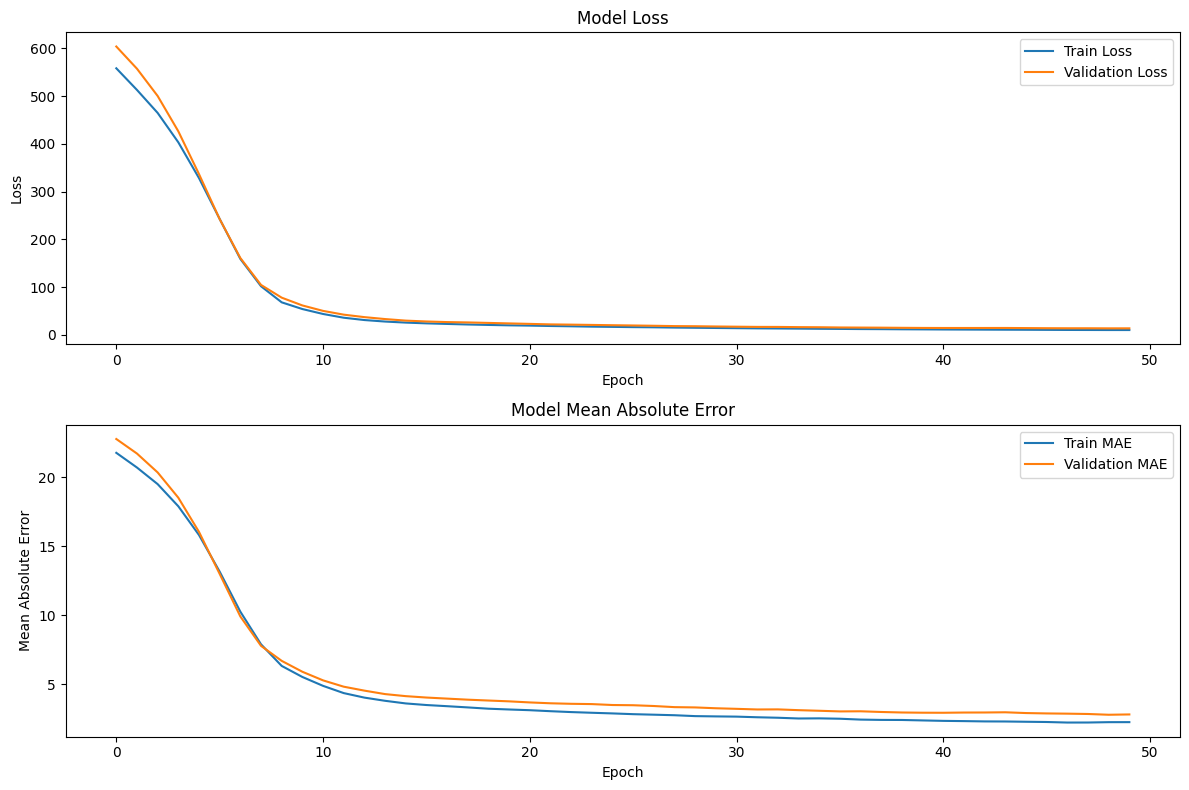

In [30]:
# Plot the training history
plt.figure(figsize=(12, 8))

# Plot training & validation loss values
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

# Plot training & validation mean absolute error values
plt.subplot(2, 1, 2)
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


# Evaluate the model

In [31]:
# Evaluate the model's performance on the training data
train_loss, train_mae = model.evaluate(train_data, train_labels)
print(f'Train Mean Absolute Error: {train_mae:.4f}')

# Evaluate the model's performance on the test data
test_loss, test_mae = model.evaluate(test_data, test_labels)
print(f'Test Mean Absolute Error: {test_mae:.4f}')


13/13 [==============================] - 0s 2ms/step - loss: 10.6653 - mean_absolute_error: 2.3431
Train Mean Absolute Error: 2.3431
4/4 [==============================] - 0s 4ms/step - loss: 21.6384 - mean_absolute_error: 3.2613
Test Mean Absolute Error: 3.2613


# Predictions

In [32]:
# Predict using the model on the test data
predictions = model.predict(test_data)

# Display the first few predictions
print(predictions[:10])

4/4 [==============================] - 0s 3ms/step
[[ 7.4975257]
 [16.443459 ]
 [21.738874 ]
 [31.634434 ]
 [26.283972 ]
 [17.020279 ]
 [25.920084 ]
 [21.775324 ]
 [19.828876 ]
 [22.966787 ]]


# Exercise (Fashion MNIST) - 60 minutes
## Opis zbioru danych
Zadanie dotyczy rozpoznawania kształtów w zbiorze Fashion MNIST. Zbiór ten składa się z 70 000 (60 000 w zbiorze uczącym i 10 000 w zbiorze testowym) czarno-białych obrazków należących do 10 kategorii. Każdy obrazek przedstawia jedno z 10 ubrań (z asortymentu Zalando) w stosunkowo słabej rozdzielczości 28x28 pikseli. Na poniższym rysunku przedstawionych jest 25 pierwszych obrazków ze zbioru uczącego.

4422102/4422102 [==============================] - 0s 0us/step


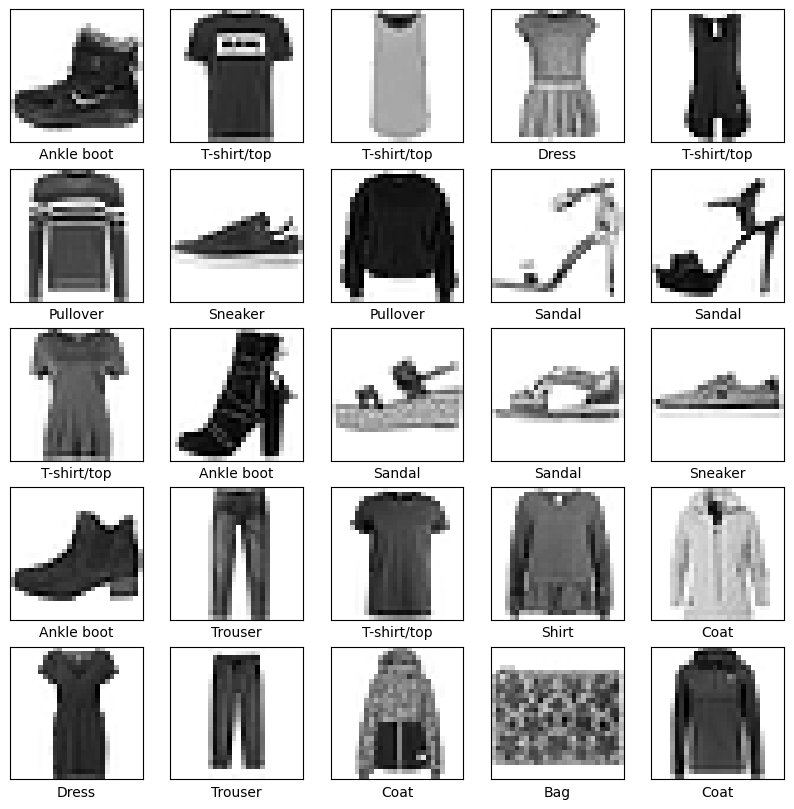

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize the images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot the first 25 images from the training set with their class names
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

Każdy piksel ma skojarzoną z nim liczbę, która określa natężenie koloru (większa wartość oznacza ciemniejszy piksel). Zmienna ta przyjmuje wartości od 0 do 255. Zbiór uczący ma 785 kolumn ($28 \times 28 = 784$ piksele oraz etykietę klasy). Więcej informacji o zbiorze danych można znaleźć na stronie [Kaggle](https://www.kaggle.com/zalando-research/fashionmnist). Zbiór można załadować używając funkcji `dataset_fashion_mnist()` z biblioteki `keras`.

## Opis zadania
Państwa zadaniem jest skonstruowanie głębokiej sieci neuronowej (minimum trzy warstwy), która będzie klasyfikowała elementy zbioru testowego. Sieć ma być nauczona jedynie na zbiorze uczącym. Miarą jakości rozwiazania jest procent poprawnej klasyfikacji, który powinien przekroczyć 87% na biorze testowym. Najlepsze obecnie rozwiązania dla tego zbioru danych osiągają ponad 97% skuteczność.

## Wymagania

1. Wyuczenie modelu (minimum 50 epok) na zbiorze uczącym.
2. Wizualne przedstawienie procesu uczenia.
3. Pokazanie skuteczności modelu na zbiorze testowym.
4. Przestawienie wyników w postaci macierzy przynależności na zbiorze testowym.
5. Porównanie rozwiązania DNN z lasem losowym (RF) oraz XGBoost.